In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
Titanic = pd.read_csv('Titanic-Dataset.csv')
Titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
Titanic.shape
Titanic.info()
Titanic.isnull().sum()

(891, 12)

In [3]:
Titanic['Age'] = Titanic.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
Titanic = Titanic.drop('Cabin', axis=1)
Titanic['Embarked'] = Titanic['Embarked'].fillna(Titanic['Embarked'].mode()[0])

Titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

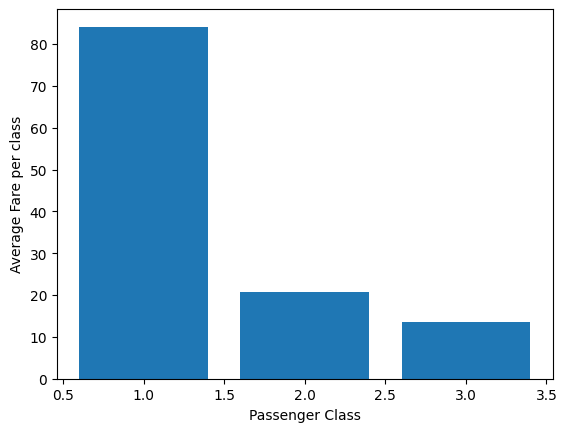

In [7]:
Fare_by_class = Titanic.groupby('Pclass')['Fare'].mean()
Fare_by_class


plt.bar(Fare_by_class.index, Fare_by_class.values)
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare per class")
plt.show()

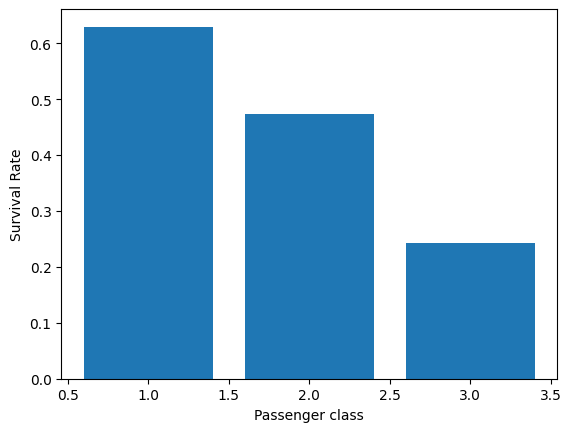

In [12]:
Survival_rate = Titanic.groupby('Pclass')['Survived'].mean()

plt.bar(Survival_rate.index,Survival_rate.values)
plt.xlabel("Passenger class")
plt.ylabel("Survival Rate")
plt.show()

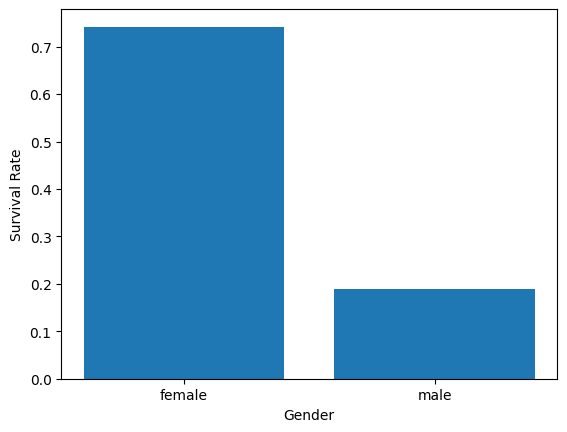

In [15]:
Survival_rate_G = Titanic.groupby('Sex')['Survived'].mean()

plt.bar(Survival_rate_G.index,Survival_rate_G.values)
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

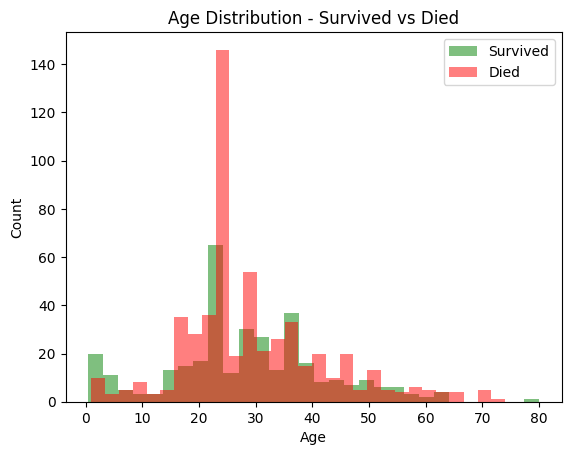

In [28]:
survived = Titanic[Titanic['Survived'] == 1]['Age']
died = Titanic[Titanic['Survived'] == 0]['Age']

plt.figure()
plt.hist(survived, bins=30, alpha=0.5, color='green', label='Survived')
plt.hist(died, bins=30, alpha=0.5, color='red', label='Died')
plt.title('Age Distribution - Survived vs Died')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()
